In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Generate dataset
n =100
products= ["Laptop", "Phone", "Tablet", "Watch"]
region= ["North", "South", "East","West"]

data= {
    "date" : pd.date_range(start="2025-01-01", periods=n),
    "Product": np.random.choice(products, n),
    "Region": np.random.choice(region,n),
    "Sales":np.random.uniform(100,1000,n)
}

df= pd.DataFrame(data)
print(".................Dataset ............")
print(df.head())

# add missing values
df.loc[4,"Sales"] = np.nan
df.loc[10,"Product"]= np.nan
print("\n........After adding missing elements......")
print(df.head())

# print missing values
print("\n...... Missing values are..........")
print(df.isnull().sum())

# Fill missing values
df["Sales"]= df["Sales"].fillna(df["Sales"].mean())
df["Product"]= df["Product"].fillna("unknown")
print("\n.........After filling missing values...........")
print(df.isnull().sum())







.................Dataset ............
        date Product Region       Sales
0 2025-01-01  Tablet  South  596.039641
1 2025-01-02  Laptop   West  959.311219
2 2025-01-03   Phone   East  188.384524
3 2025-01-04   Phone   East  344.247880
4 2025-01-05   Phone  South  778.237572

........After adding missing elements......
        date Product Region       Sales
0 2025-01-01  Tablet  South  596.039641
1 2025-01-02  Laptop   West  959.311219
2 2025-01-03   Phone   East  188.384524
3 2025-01-04   Phone   East  344.247880
4 2025-01-05   Phone  South         NaN

...... Missing values are..........
date       0
Product    1
Region     0
Sales      1
dtype: int64

.........After filling missing values...........
date       0
Product    0
Region     0
Sales      0
dtype: int64


In [3]:
#Total sales per product
Total_sale= df.groupby("Product")["Sales"].sum()
print("\n......Total sale per product is:.........")
print(Total_sale)

# Region wise performance
region_sale= df.groupby("Region")["Sales"].sum()
print("\n..........Region wise performance ...............")
print(region_sale)


......Total sale per product is:.........
Product
Laptop     18024.409648
Phone      14752.835548
Tablet     10181.416317
Watch       8529.800863
unknown      990.169986
Name: Sales, dtype: float64

..........Region wise performance ...............
Region
East     16019.821072
North    11802.085402
South    14767.685883
West      9889.040005
Name: Sales, dtype: float64


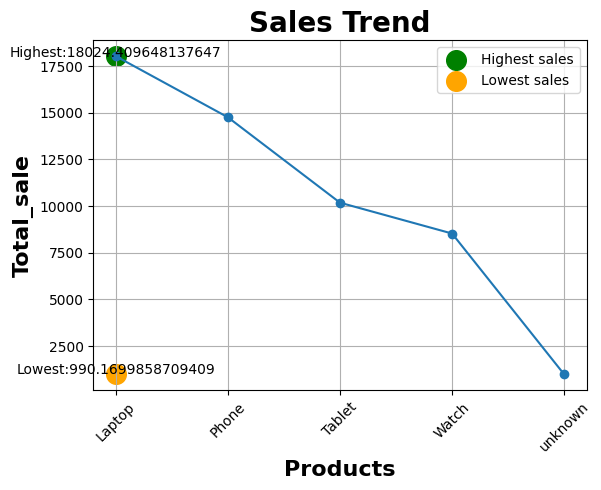

In [ ]:
# Sales trend(line chart)
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.plot(Total_sale.index, Total_sale.values, marker="o")
plt.title("Sales Trend", fontsize=20,fontweight="bold")
plt.xlabel("Products", fontweight="bold", fontsize=16)
plt.ylabel("Total_sale", fontweight="bold", fontsize=16)

highest_sale= Total_sale.max()
highest_day = Total_sale.idxmax()
lowest_sale = Total_sale.min()
lowest_day = Total_sale.idxmax()

plt.scatter(highest_day, highest_sale , label= "Highest sales", s= 200,color= "green")
plt.scatter(lowest_day, lowest_sale , label= "Lowest sales", s= 200,color= "orange")


plt.text(highest_day, highest_sale-10 , f'Highest:{highest_sale}', ha='center')
plt.text(lowest_day, lowest_sale +10, f'Lowest:{lowest_sale}', ha='center')

plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.show()





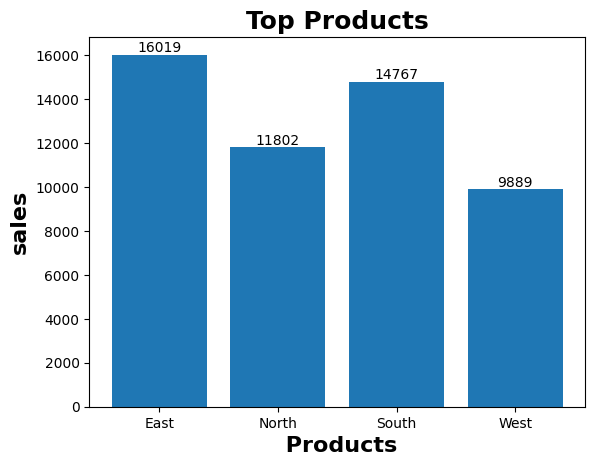

In [ ]:
# find top products (bar chart)
bars = plt.bar(region_sale.index, region_sale.values)
plt.title("Top Products", fontsize= 18, fontweight= "bold")
plt.xlabel(" Products", fontsize= 16, fontweight= "bold")
plt.ylabel("sales", fontsize= 16, fontweight= "bold")

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )
plt.show()

In [31]:
#Best performance region 
Best_region = region_sale.idxmax()
print("Best Performance Region:", Best_region)

#Highest selling product
Top_product = Total_sale.idxmax()
print("Highest selling product:", Top_product)

#Average sale
avg_sale= df["Sales"].mean()
print("Average sale is:",avg_sale)


print("\n=====================")
print("KEY INSIGHTS")
print("=====================")

print(f"1. Highest selling product is {Top_product}.")

print(f"2. Best performing region is {Best_region}.")

print(f"3. Average sales value = {avg_sale:.2f}")

Best Performance Region: East
Highest selling product: Laptop
Average sale is: 524.7863236152928

KEY INSIGHTS
1. Highest selling product is Laptop.
2. Best performing region is East.
3. Average sales value = 524.79
